# Deskripsi Tugas
"Sistem ini dirancang untuk melakukan penghitungan berbasis puncak (peak count). Untuk setiap video, sistem memproses seluruh frame dan melaporkan jumlah maksimum orang yang terdeteksi secara bersamaan dalam satu frame sebagai hasil prediksi akhir. Metodologi ini dipilih untuk mengukur kepadatan maksimum orang dalam sebuah adegan dan merupakan pendekatan standar untuk validasi awal sistem penghitungan."

# LANGKAH 0: SETUP LINGKUNGAN

In [1]:
# =============================================================
# NOTEBOOK VALIDASI AKURASI SISTEM HUMAN COUNTING
# =============================================================
# Tujuan: Memvalidasi performa model fine-tuned pada tugas
#         menghitung orang dalam video dan membuat laporan
#         akurasi hitungan.
# =============================================================

# -----------------------------------------------------
# LANGKAH 0: SETUP LINGKUNGAN
# -----------------------------------------------------
print("📦 Menginstal/Memeriksa library yang dibutuhkan...")
!pip install ultralytics pandas openpyxl -q

import os
import cv2
import pandas as pd
from ultralytics import YOLO
from google.colab import drive
from google.colab.patches import cv2_imshow
import time

print("✅ Library berhasil diimpor.")

# Hubungkan ke Google Drive
drive.mount('/content/drive')
print("✅ Google Drive berhasil terhubung.")

📦 Menginstal/Memeriksa library yang dibutuhkan...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.6 MB/s eta 0:00

In [2]:
# -----------------------------------------------------
# LANGKAH 1: KONFIGURASI & PEMUATAN MODEL
# -----------------------------------------------------
print("\n⚙️ Memuat konfigurasi dan model...")

# === KONFIGURASI WAJIB DIISI ===
# 1. Path ke model terbaik Anda (best.pt dari training Anda)
PATH_MODEL_TERBAIK = '/content/drive/MyDrive/Magang KP Model AI/Model Total Count/v0.5.0/PersonDetection_LargeDataset_Run1/weights/best.pt'

# 2. Path ke folder di Google Drive tempat Anda menyimpan 10 video tes
PATH_FOLDER_VIDEO_INPUT = '/content/drive/MyDrive/Magang KP Model AI/Model Total Count/Video Uji Human Count/'

# 3. Path ke folder di Google Drive untuk menyimpan HASIL (video + laporan)
PATH_FOLDER_OUTPUT = '/content/drive/MyDrive/Magang KP Model AI/Model Total Count/Hasil Validasi Human Count/'
os.makedirs(PATH_FOLDER_OUTPUT, exist_ok=True) # Buat folder jika belum ada

# 4. KUNCI JAWABAN (GROUND TRUTH) - (Wajib Diisi Manual!)
# Format: 'nama_file_video.mp4': jumlah_orang_sebenarnya
# PENTING: Hitung manual dan isi jumlah orang terbanyak di setiap video.
GROUND_TRUTH_COUNTS = {
    'video_keramaian_1.mp4': 2,
    'video_keramaian_2.mp4': 2,
    'video_keramaian_3.mp4': 4,
    'video_keramaian_4.mp4': 5,
    'video_keramaian_5.mp4': 3,
    # Lanjutkan sampai 10 video...
    # 'nama_video_6.mp4': 6,
    # 'nama_video_7.mp4': 1,
    # 'nama_video_8.mp4': 10,
    # 'nama_video_9.mp4': 7,
    # 'nama_video_10.mp4': 9,
}
# ===============================

try:
    model = YOLO(PATH_MODEL_TERBAIK)
    # Mencari tahu ID kelas 'person'. Kita asumsikan dari notebook Anda,
    # urutannya: gun, person, person with a gun. Jadi, 'person' adalah ID 1.
    # Kita cek untuk memastikan.
    person_class_id = -1
    for class_id, class_name in model.names.items():
        if class_name.lower() == 'person':
            person_class_id = class_id
            break

    if person_class_id == -1:
         raise ValueError("Kelas 'person' tidak ditemukan di model.names. Cek file data.yaml Anda.")

    print(f"✅ Model berhasil dimuat dari: {PATH_MODEL_TERBAIK}")
    print(f"✅ Kelas 'person' teridentifikasi dengan ID: {person_class_id}")
    print(f"✅ Siap memproses video dari: {PATH_FOLDER_VIDEO_INPUT}")
    print(f"✅ Hasil akan disimpan di: {PATH_FOLDER_OUTPUT}")
except Exception as e:
    print(f"❌ Gagal memuat model atau konfigurasi: {e}")
    # Berhenti jika model gagal dimuat
    exit()




⚙️ Memuat konfigurasi dan model...
✅ Model berhasil dimuat dari: /content/drive/MyDrive/Magang KP Model AI/Model Total Count/v0.5.0/PersonDetection_LargeDataset_Run1/weights/best.pt
✅ Kelas 'person' teridentifikasi dengan ID: 1
✅ Siap memproses video dari: /content/drive/MyDrive/Magang KP Model AI/Model Total Count/Video Uji Human Count/
✅ Hasil akan disimpan di: /content/drive/MyDrive/Magang KP Model AI/Model Total Count/Hasil Validasi Human Count/


In [3]:
# ================================================================
# LANGKAH 2: FUNGSI UTAMA UNTUK PROSES & VALIDASI VIDEO (PERBAIKAN FINAL)
# ================================================================
# Logika Skor Persentase diperbaiki untuk menangani over-prediction dengan benar.
# ================================================================
# Fungsi baru untuk menggambar teks dengan background
def draw_text_with_bg(frame, text, position, font_scale=1.0, thickness=2):
    """Menggambar teks dengan background hitam semi-transparan agar lebih mudah dibaca."""
    font = cv2.FONT_HERSHEY_SIMPLEX
    text_size, _ = cv2.getTextSize(text, font, font_scale, thickness)
    text_w, text_h = text_size

    # Koordinat untuk background rectangle
    bg_x1, bg_y1 = position
    bg_x2, bg_y2 = bg_x1 + text_w + 10, bg_y1 + text_h + 10

    # Buat overlay semi-transparan
    sub_img = frame[bg_y1:bg_y2, bg_x1:bg_x2]
    black_rect = np.zeros(sub_img.shape, dtype=np.uint8)
    res = cv2.addWeighted(sub_img, 0.6, black_rect, 0.4, 1.0)
    frame[bg_y1:bg_y2, bg_x1:bg_x2] = res

    # Tulis teks di atas background
    cv2.putText(frame, text, (bg_x1 + 5, bg_y1 + text_h + 5), font, font_scale, (255, 255, 255), thickness)

    return frame

def validate_human_count_on_videos(video_folder, output_folder, model, ground_truth):
    """
    Fungsi untuk memproses semua video di folder, menghitung orang,
    membandingkan dengan ground truth menggunakan berbagai metrik,
    dan menyimpan hasilnya.
    """
    video_files = [f for f in os.listdir(video_folder) if f.endswith(('.mp4', '.avi', '.mov'))]
    report_data = []
    correctly_predicted_videos = 0
    total_absolute_error = 0
    total_percentage_score = 0

    print("\n" + "="*60)
    print("🚀 MEMULAI PROSES VALIDASI PADA SEMUA VIDEO...")
    print("="*60)

    for video_name in video_files:
        if video_name not in ground_truth:
            print(f"\n⚠️ Peringatan: Video '{video_name}' dilewati karena tidak ada di GROUND_TRUTH_COUNTS.")
            continue

        video_path = os.path.join(video_folder, video_name)
        output_video_path = os.path.join(output_folder, f"hasil_{video_name}")

        print(f"\n🔄 Memproses: {video_name}")
        start_time = time.time()

        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"   ❌ Error: Gagal membuka video {video_name}.")
            continue

        frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        out = cv2.VideoWriter(output_video_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

        frame_by_frame_counts = []

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # Deteksi objek
            detections = model.predict(frame, classes=[person_class_id], conf=0.7, verbose=False)
            current_person_count = len(detections[0].boxes)
            frame_by_frame_counts.append(current_person_count)

            # === PERBAIKAN DI SINI ===
            # 1. Buat 'annotated_frame' dengan menggambar kotak deteksi.
            annotated_frame = detections[0].plot()

            # 2. Ambil nilai max_count DARI SEMUA FRAME YANG SUDAH DILIHAT
            max_count_so_far = max(frame_by_frame_counts) if frame_by_frame_counts else 0

            # 3. Sekarang gambar teks ke 'annotated_frame' yang sudah ada
            annotated_frame = draw_text_with_bg(
                annotated_frame,
                f"Deteksi Frame Ini: {current_person_count}",
                position=(10, 10), font_scale=1.0, thickness=2
            )
            annotated_frame = draw_text_with_bg(
                annotated_frame,
                f"Prediksi Total (Max): {max_count_so_far}",
                position=(10, 60), font_scale=1.0, thickness=2
            )
            # === AKHIR PERBAIKAN ===

            out.write(annotated_frame)

        cap.release()
        out.release()

        # Hitung prediksi final setelah semua frame diproses
        predicted_count_final = max(frame_by_frame_counts) if frame_by_frame_counts else 0

        # === Perhitungan metrik tetap sama seperti sebelumnya ===
        actual_count = ground_truth.get(video_name)
        current_error = abs(actual_count - predicted_count_final)
        total_absolute_error += current_error

        percentage_score_for_video = 0.0
        if actual_count > 0:
            relative_error = current_error / actual_count
            percentage_score_for_video = max(0.0, 1.0 - relative_error)
        elif current_error == 0:
            percentage_score_for_video = 1.0

        total_percentage_score += percentage_score_for_video

        is_correct = (current_error == 0)
        if is_correct:
            correctly_predicted_videos += 1

        end_time = time.time()
        duration = end_time - start_time

        print(f"   - Waktu Proses: {duration:.2f} detik")
        print(f"   - Jumlah Sebenarnya (Manual): {actual_count}")
        print(f"   - Prediksi Sistem (Max Count):  {predicted_count_final}")
        print(f"   - Skor Persentase (Revisi): {percentage_score_for_video:.2%}")
        print(f"   - Hasil Exact Match: {'✅ BENAR' if is_correct else '❌ SALAH'}")

        report_data.append({
            "Nama Video": video_name, "Jml Sebenarnya (GT)": actual_count,
            "Jml Prediksi Sistem": predicted_count_final, "Skor Persentase": f"{percentage_score_for_video:.2%}",
            "Hasil Exact Match": "Benar" if is_correct else "Salah", "Error (Selisih)": current_error
        })

    # Kalkulasi Akurasi Final (tidak berubah)
    num_videos_processed = len(report_data)
    if num_videos_processed > 0:
        final_percentage_accuracy = (total_percentage_score / num_videos_processed) * 100
        final_exact_accuracy = (correctly_predicted_videos / num_videos_processed) * 100
        mean_absolute_error = (total_absolute_error / num_videos_processed)
    else:
        final_percentage_accuracy, final_exact_accuracy, mean_absolute_error = 0, 0, 0

    return report_data, final_percentage_accuracy, final_exact_accuracy, mean_absolute_error

In [8]:

# =====================================================
# LANGKAH 3: EKSEKUSI & PELAPORAN (PERBAIKAN FINAL)
# =====================================================
# Panggilan fungsi sama, tapi judul di laporan diubah agar lebih jelas
report, main_accuracy, exact_accuracy, mae = validate_human_count_on_videos(
    PATH_FOLDER_VIDEO_INPUT,
    PATH_FOLDER_OUTPUT,
    model,
    GROUND_TRUTH_COUNTS
)

# Tampilkan Laporan Akhir yang Komprehensif
print("\n" + "="*60)
print("✨ LAPORAN AKHIR VALIDASI SISTEM HUMAN COUNTING ✨")
print("="*60)
print(f"🎯 AKURASI UTAMA (Berdasarkan Skor Persentase): {main_accuracy:.2f}%")
print(f"   (Skor dihitung sbg 1 - |Error|/Aktual. Lebih adil utk over-prediction)")
print("-" * 30)
print("METRIK TAMBAHAN UNTUK ANALISIS LEBIH DALAM:")
print(f"📊 Akurasi Ketepatan (Exact Match): {exact_accuracy:.2f}%")
print(f"   (Persentase video yang hitungannya 100% benar)")
print("")
print(f"📈 Mean Absolute Error (MAE): {mae:.2f}")
print(f"   (Rata-rata, sistem meleset sebanyak {mae:.2f} orang per video)")
print("-" * 60)

# Rangkuman Detail
df_report = pd.DataFrame(report)
kolom_urut = [
    "Nama Video",
    "Jml Sebenarnya (GT)",
    "Jml Prediksi Sistem",
    "Skor Persentase",
    "Hasil Exact Match",
    "Error (Selisih)"
]
print("📋 Rangkuman Hasil Detail per Video:")
print(df_report[kolom_urut].to_string(index=False))

# Simpan ke Excel
excel_report_path = os.path.join(PATH_FOLDER_OUTPUT, 'Laporan_Akurasi_Final_Human_Count.xlsx')
try:
    df_report[kolom_urut].to_excel(excel_report_path, index=False, engine='openpyxl')
    print("-" * 60)
    print(f"✅ Laporan lengkap berhasil disimpan sebagai file Excel di:")
    print(f"   {excel_report_path}")
except Exception as e:
     print(f"❌ Gagal menyimpan ke Excel. Error: {e}")
print("==========================================================")


🚀 MEMULAI PROSES VALIDASI PADA SEMUA VIDEO...

🔄 Memproses: video_keramaian_1.mp4
   - Waktu Proses: 10.33 detik
   - Jumlah Sebenarnya (Manual): 2
   - Prediksi Sistem (Max Count):  2
   - Skor Persentase (Revisi): 100.00%
   - Hasil Exact Match: ✅ BENAR

🔄 Memproses: video_keramaian_2.mp4
   - Waktu Proses: 62.89 detik
   - Jumlah Sebenarnya (Manual): 2
   - Prediksi Sistem (Max Count):  2
   - Skor Persentase (Revisi): 100.00%
   - Hasil Exact Match: ✅ BENAR

🔄 Memproses: video_keramaian_3.mp4
   - Waktu Proses: 43.97 detik
   - Jumlah Sebenarnya (Manual): 4
   - Prediksi Sistem (Max Count):  4
   - Skor Persentase (Revisi): 100.00%
   - Hasil Exact Match: ✅ BENAR

🔄 Memproses: video_keramaian_4.mp4
   - Waktu Proses: 48.54 detik
   - Jumlah Sebenarnya (Manual): 5
   - Prediksi Sistem (Max Count):  5
   - Skor Persentase (Revisi): 100.00%
   - Hasil Exact Match: ✅ BENAR

🔄 Memproses: video_keramaian_5.mp4
   - Waktu Proses: 40.05 detik
   - Jumlah Sebenarnya (Manual): 3
   - Predik


🎥 DEMO REAL-TIME (Visualisasi Profesional)
Menggunakan model: /content/drive/MyDrive/Magang KP Model AI/Model Total Count/v0.5.0/PersonDetection_LargeDataset_Run1/weights/best.pt
Resolusi Deteksi: 640px | Confidence: 0.5
✅ Koneksi Berhasil! Mulai merekam ke: /content/drive/MyDrive/Magang KP Model AI/Model Total Count/Hasil Validasi Human Count/demo_visual_profesional.mp4
Frame #1 | Orang Terdeteksi: 0
Frame #2 | Orang Terdeteksi: 0
Frame #3 | Orang Terdeteksi: 0
Frame #4 | Orang Terdeteksi: 1
Frame #5 | Orang Terdeteksi: 1
Frame #6 | Orang Terdeteksi: 1
Frame #7 | Orang Terdeteksi: 1
Frame #8 | Orang Terdeteksi: 1
Frame #9 | Orang Terdeteksi: 1
Frame #10 | Orang Terdeteksi: 1
Frame #11 | Orang Terdeteksi: 1
Frame #12 | Orang Terdeteksi: 1
Frame #13 | Orang Terdeteksi: 1
Frame #14 | Orang Terdeteksi: 1
Frame #15 | Orang Terdeteksi: 1
Frame #16 | Orang Terdeteksi: 1
Frame #17 | Orang Terdeteksi: 1
Frame #18 | Orang Terdeteksi: 0
Frame #19 | Orang Terdeteksi: 0
Frame #20 | Orang Terdetek

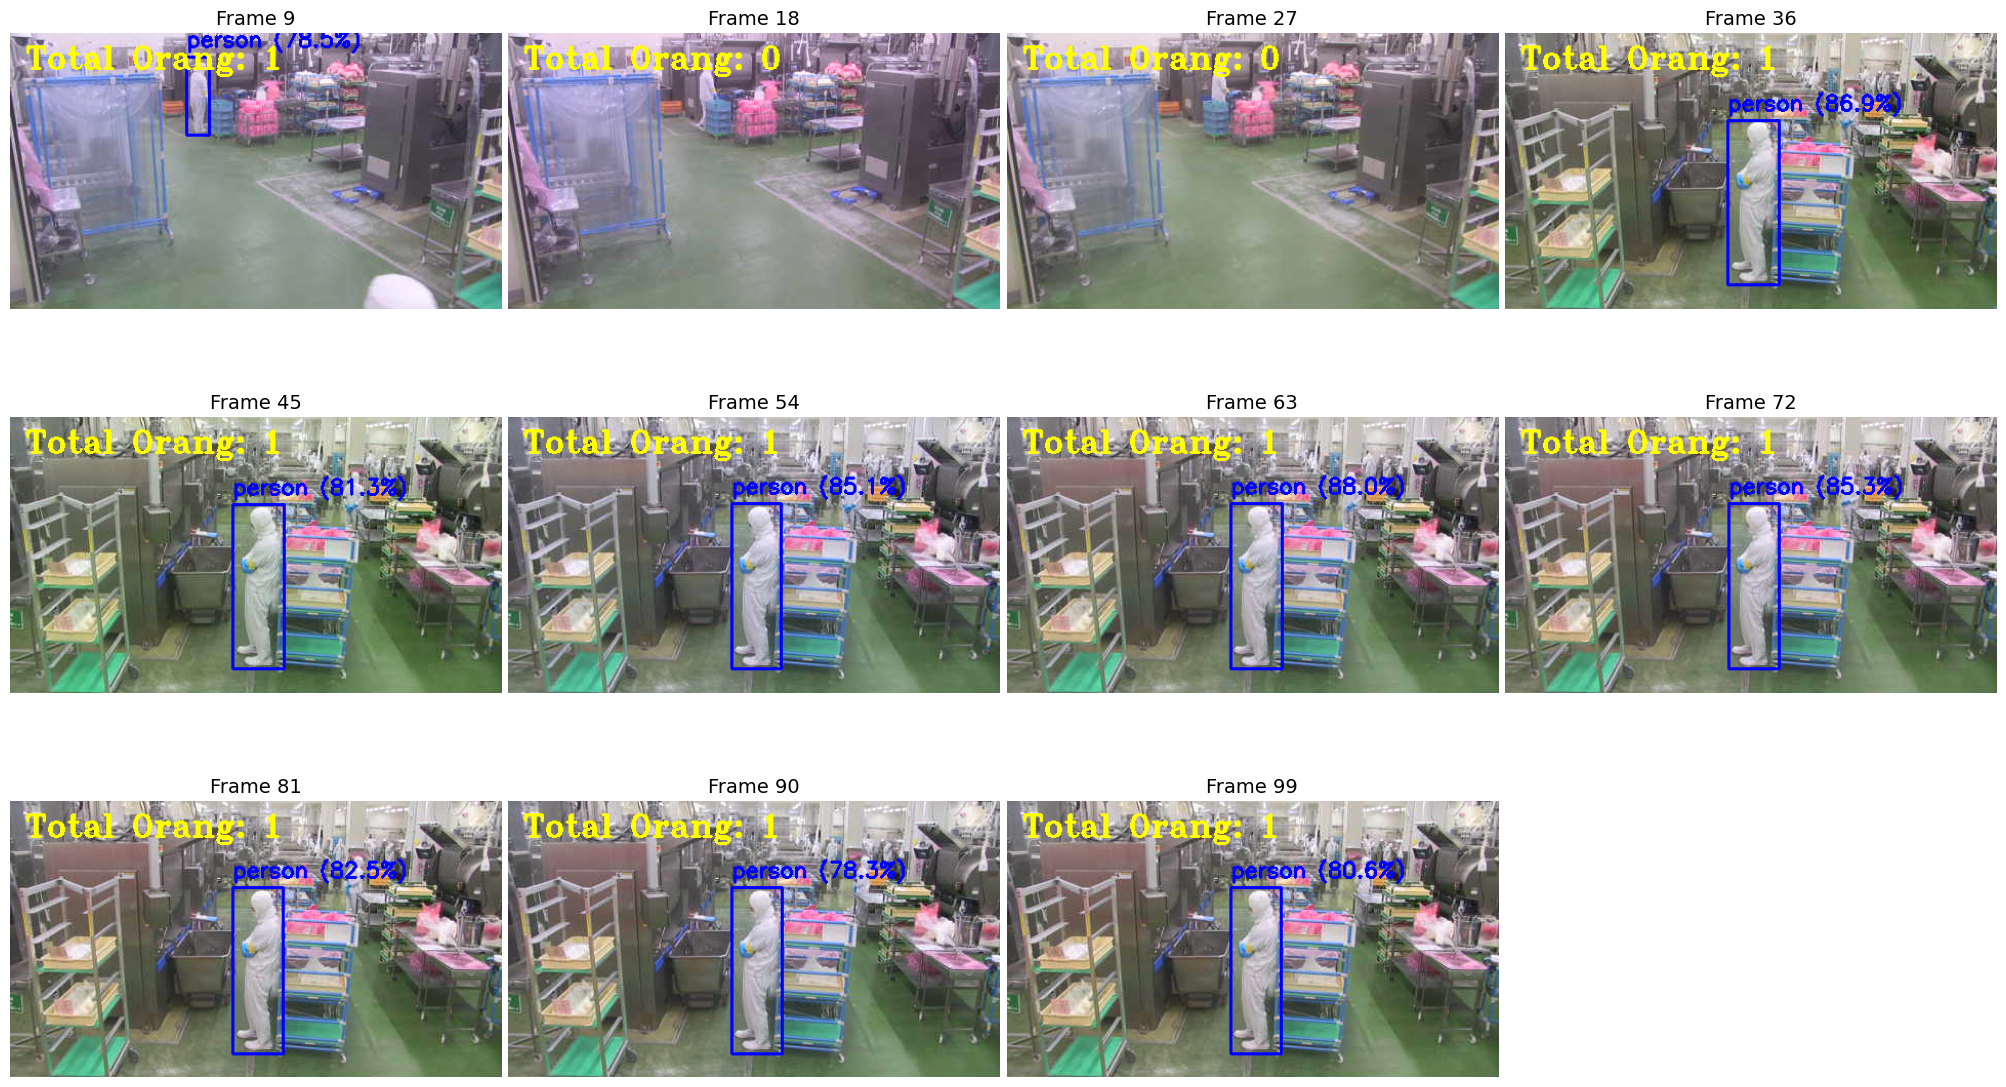


🏁 Demo selesai.


In [14]:
# ==================================================================================
# SEL DEMO IP CAMERA (VERSI FINAL VISUAL - Tampilan Profesional)
# ==================================================================================
# Fokus pada pembuatan output visual yang bersih, informatif, dan mirip
# dengan contoh terbaik yang Anda berikan.

import requests
import time
from google.colab.patches import cv2_imshow
import traceback
import numpy as np
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("🎥 DEMO REAL-TIME (Visualisasi Profesional)")
print("="*60)

# --- KONFIGURASI ---
IP_CAMERA_URL = "http://153.156.230.207:8084/-wvhttp-01-/GetOneShot?image_size=640x480&frame_count=1000000000"
MAX_FRAMES_TO_PROCESS = 100
OUTPUT_DEMO_VIDEO_NAME = 'demo_visual_profesional.mp4'

# --- KENOP KUALITAS & KECEPATAN ---
CONFIDENCE_THRESHOLD = 0.5
IMG_SIZE = 640

# --- Konfigurasi Gambar Sampel ---
# Kita akan buat logic agar gridnya menjadi 4x3 (total 12 gambar)
SAMPLE_EVERY_N_FRAMES = (MAX_FRAMES_TO_PROCESS // 12) + 1 if MAX_FRAMES_TO_PROCESS >= 12 else 1
MAX_SAMPLE_IMAGES = 12
sample_data_list = []
# ====================

if 'model' not in locals() or 'PATH_FOLDER_OUTPUT' not in locals() or 'person_class_id' not in locals():
    print("❌ Error: Pastikan LANGKAH 1 sudah dijalankan.")
else:
    print(f"Menggunakan model: {PATH_MODEL_TERBAIK}")
    print(f"Resolusi Deteksi: {IMG_SIZE}px | Confidence: {CONFIDENCE_THRESHOLD}")

    output_video_path = os.path.join(PATH_FOLDER_OUTPUT, OUTPUT_DEMO_VIDEO_NAME)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_video_writer = None

    frame_count = 0
    try:
        cap = cv2.VideoCapture(IP_CAMERA_URL)
        if not cap.isOpened():
            print("⚠️ Peringatan: cv2.VideoCapture gagal membuka URL.")

        while frame_count < MAX_FRAMES_TO_PROCESS:
            ret, frame = cap.read()
            if not ret:
                print("Gagal membaca frame, mencoba menghubungkan ulang...")
                cap.release(); time.sleep(2); cap = cv2.VideoCapture(IP_CAMERA_URL); continue

            frame_count += 1
            if out_video_writer is None:
                h, w, _ = frame.shape
                out_video_writer = cv2.VideoWriter(output_video_path, fourcc, 20.0, (w, h))
                print(f"✅ Koneksi Berhasil! Mulai merekam ke: {output_video_path}")

            # Deteksi
            detections = model.predict(frame, classes=[person_class_id], conf=CONFIDENCE_THRESHOLD, verbose=False, imgsz=IMG_SIZE)
            current_people_count = len(detections[0].boxes)
            print(f"Frame #{frame_count} | Orang Terdeteksi: {current_people_count}")

            # --- VISUALISASI MANUAL (BUKAN .plot()) ---
            annotated_frame = frame.copy() # Mulai dengan frame asli yang bersih

            for box in detections[0].boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                conf = float(box.conf[0])
                cls_name = model.names[int(box.cls[0])]

                # Gambar Bounding Box (Biru)
                cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (255, 0, 0), 2)

                # Buat Label Teks (Biru)
                label_text = f"{cls_name} ({conf*100:.1f}%)"
                cv2.putText(annotated_frame, label_text, (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

            # Tulis Teks Jumlah Total (Kuning)
            cv2.putText(annotated_frame, f"Total Orang: {current_people_count}", (15, 35),
                        cv2.FONT_HERSHEY_TRIPLEX, 1, (0, 255, 255), 2)
            # ===============================================

            # Pengambilan sampel
            if (frame_count % SAMPLE_EVERY_N_FRAMES == 0) and (len(sample_data_list) < MAX_SAMPLE_IMAGES):
                sample_data_list.append({
                    "image": cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB),
                    "frame_num": frame_count
                })

            # Tulis ke video
            if out_video_writer is not None:
                out_video_writer.write(annotated_frame)

        print(f"\n✅ Berhasil memproses {MAX_FRAMES_TO_PROCESS} frame.")
    except KeyboardInterrupt:
        print("\n⏹️ Demo dihentikan oleh pengguna.")
    finally:
        if 'cap' in locals() and cap.isOpened(): cap.release()
        if out_video_writer is not None: out_video_writer.release()
        print(f"\n✅ Video demo telah disimpan di: {output_video_path}")

        # --- TAMPILKAN GRID VISUAL AKHIR ---
        print("\n" + "="*50)
        print("🖼️ RANGKUMAN VISUAL FINAL DARI HASIL DEMO")
        print("="*50)
        if sample_data_list:
            # Atur grid menjadi 4 kolom
            cols = 4
            rows = (len(sample_data_list) + cols - 1) // cols

            plt.figure(figsize=(cols * 5, rows * 4)) # Buat figur lebih besar

            for i, data in enumerate(sample_data_list):
                plt.subplot(rows, cols, i + 1)
                plt.imshow(data["image"])
                plt.title(f"Frame {data['frame_num']}", fontsize=14)
                plt.axis('off')

            plt.tight_layout(pad=0.5)
            plt.show()
        else:
            print("Tidak ada gambar sampel yang berhasil diambil.")

        print("\n🏁 Demo selesai.")

In [5]:
# =============================================================
# SEL OPSIONAL: EKSPOR MODEL KE TFLITE
# =============================================================
# Jalankan sel ini untuk mengonversi model 'best.pt' Anda
# ke dalam format TFLite (float32, float16, int8).
# Model harus sudah dimuat dari LANGKAH 1.
# Hasil akan disimpan di folder output Anda.

import shutil

print("\n" + "="*50)
print("🚀 EKSPOR MODEL KE FORMAT TFLITE")
print("="*50)

# Cek jika model dan path output sudah siap
if 'model' not in locals() or 'PATH_FOLDER_OUTPUT' not in locals():
    print("❌ Error: Model atau path output belum di-setup. Jalankan LANGKAH 1 terlebih dahulu.")
else:
    print(f"Model sumber: {model.ckpt_path}")
    print(f"Hasil ekspor akan disimpan di: {PATH_FOLDER_OUTPUT}")

    try:
        # --- 1. Export ke TFLite (float32) - Presisi Penuh ---
        print("\n(1/3) Mengekspor ke float32...")
        tflite_fp32_path = model.export(format='tflite', imgsz=640, verbose=False)
        final_fp32_path = os.path.join(PATH_FOLDER_OUTPUT, os.path.basename(tflite_fp32_path))
        shutil.move(tflite_fp32_path, final_fp32_path)
        print(f"✅ Berhasil! Model disimpan di: {final_fp32_path}")

        # --- 2. Export ke TFLite (float16) - Setengah Presisi ---
        print("\n(2/3) Mengekspor ke float16...")
        tflite_fp16_path = model.export(format='tflite', imgsz=640, half=True, verbose=False)
        final_fp16_path = os.path.join(PATH_FOLDER_OUTPUT, os.path.basename(tflite_fp16_path))
        shutil.move(tflite_fp16_path, final_fp16_path)
        print(f"✅ Berhasil! Model disimpan di: {final_fp16_path}")

        # --- 3. Export ke TFLite (int8) - Quantisasi Integer ---
        print("\n(3/3) Mengekspor ke int8...")
        # Penting: int8 butuh dataset kalibrasi. Kita akan pakai dataset `data.yaml` yang sama.
        # Pastikan variabel data_yaml_path masih ada dari sel sebelumnya.
        if 'data_yaml_path' in locals() and os.path.exists(data_yaml_path):
             tflite_int8_path = model.export(format='tflite', imgsz=640, int8=True, data=data_yaml_path, verbose=False)
             final_int8_path = os.path.join(PATH_FOLDER_OUTPUT, os.path.basename(tflite_int8_path))
             shutil.move(tflite_int8_path, final_int8_path)
             print(f"✅ Berhasil! Model disimpan di: {final_int8_path}")
        else:
            print("   ⚠️ Peringatan: Tidak bisa menemukan data.yaml untuk kalibrasi int8.")
            print("   - Mengekspor tanpa data kalibrasi (performa mungkin kurang optimal).")
            tflite_int8_path = model.export(format='tflite', imgsz=640, int8=True, verbose=False)
            final_int8_path = os.path.join(PATH_FOLDER_OUTPUT, os.path.basename(tflite_int8_path))
            shutil.move(tflite_int8_path, final_int8_path)
            print(f"✅ Berhasil! Model disimpan di: {final_int8_path}")

        print("\n🎉 Semua proses ekspor TFLite selesai!")

    except Exception as e:
        print(f"\n❌ Gagal saat mengekspor: {e}")


🚀 EKSPOR MODEL KE FORMAT TFLITE
Model sumber: /content/drive/MyDrive/Magang KP Model AI/Model Total Count/v0.5.0/PersonDetection_LargeDataset_Run1/weights/best.pt
Hasil ekspor akan disimpan di: /content/drive/MyDrive/Magang KP Model AI/Model Total Count/Hasil Validasi Human Count/

(1/3) Mengekspor ke float32...
Ultralytics 8.3.177 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 92 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Magang KP Model AI/Model Total Count/v0.5.0/PersonDetection_LargeDataset_Run1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (49.6 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0,<1.4.0', 'onnx>=1.12.0,<1.18.0', 'onnx2tf>=1.

Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /content/calibration_image_sample_data_20x128x128x3_float32.npy...: 100%|██████████| 1/1 [00:00<00:00, 50.74file/s]



ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.64...
ONNX: export success ✅ 6.6s, saved as '/content/drive/MyDrive/Magang KP Model AI/Model Total Count/v0.5.0/PersonDetection_LargeDataset_Run1/weights/best.onnx' (98.9 MB)
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.2...
Saved artifact at '/content/drive/MyDrive/Magang KP Model AI/Model Total Count/v0.5.0/PersonDetection_LargeDataset_Run1/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 7, 8400), dtype=tf.float32, name=None)
Captures:
  138965022069904: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  138965022069520: TensorSpec(shape=(3, 3, 3, 48), dtype=tf.float32, name=None)
  138965022070288: TensorSpec(shape=(48,), dtype=tf.float32, name=None)
  138965022071824: TensorSpec(shape=(4, 2), dtype

Unzipping /content/datasets/coco8.zip to /content/datasets/coco8...: 100%|██████████| 25/25 [00:00<00:00, 4004.03file/s]

Dataset download success ✅ (0.7s), saved to /content/datasets



Fast image access ✅ (ping: 0.0±0.0 ms, read: 945.9±447.1 MB/s, size: 54.0 KB)



Scanning /content/datasets/coco8/labels/val... 4 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4/4 [00:00<00:00, 110.76it/s]

New cache created: /content/datasets/coco8/labels/val.cache
WARNING ⚠️ TensorFlow SavedModel: >300 images recommended for INT8 calibration, found 4 images.


TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.2...
Saved artifact at '/content/drive/MyDrive/Magang KP Model AI/Model Total Count/v0.5.0/PersonDetection_LargeDataset_Run1/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 7, 8400), dtype=tf.float32, name=None)
Captures:
  138964954226640: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  138964954227024: TensorSpec(shape=(3, 3, 3, 48), dtype=tf.float32, name=None)
  138964954225872: TensorSpec(shape=(48,), dtype=tf.float32, name=None)
  138964954227792: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  138964954224912: TensorSpec(shape=(3, 3, 48, 96), dtype=tf.float32, name=None)
  138964954226064: TensorSpec(shape=(96,), dtype=tf.float32, name=None)
  138964954229520: TensorSpec(shape=(1, 1, 96, 96), dtype=tf.float32, name=None)
  13